# Steel Industry Energy Consumption - Part 2: Regression Modeling

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)
RANDOM_STATE = 42

## 1. Load Dataset with Engineered Features from part 1

In [ ]:
df = pd.read_csv('data/Steel_industry_data_cleaned.csv')

df.head()


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,hour,day_of_week_num,month,is_weekend,power_factor_ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,1,1,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,1,1,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,1,1,0,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,1,1,0,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,1,1,0,1.545117,0


## 2. Drop Orignal Date Column and Target-leaking Columns

- `Date`: the raw timestamp itselt isn't usable by a model directly - its useful infromation is already captured in `hour`, `day_of_week_num`, `month`, `is_weeknd`.
- `high_Load`: this was build directly from `Usage_kwh` in part 1 (1 if usage is above 75 percentile). Since it'a a direct function of the targe, keeping it would leak the answer straight into the model/
- `WeekStatus`: dropped because it's the same information already encoded numerically in `is_weekend`

In [73]:
df_model = df.drop(columns = ['date', 'High_Load', 'WeekStatus'], errors = 'ignore')

`power_factor_ratio` contain small number of `NaN` values. Regression model can't train with `NaN` so these are filled with the columns' median before modeling

In [74]:
n_missing = df_model['power_factor_ratio'].isna().sum()
print(f"Missing Values in Power_factor_ratio: {n_missing}")

df_model['power_factor_ratio'] = df_model['power_factor_ratio'].fillna(
    df_model['power_factor_ratio'].median()
)

print (f"Missing Values after fill: {df_model['power_factor_ratio'].isna().sum()}")

Missing Values in Power_factor_ratio: 1
Missing Values after fill: 0


## 3. Encode Categorical Columns

In [75]:
df_model = df_model.drop(columns = ['day_of_week_num'])

df_encoded = pd.get_dummies(df_model, columns = ['Load_Type', 'Day_of_week'], drop_first = True)

print (df_encoded.shape)


(35040, 19)


## 4. Train-Test Split (80/20, random_state = 42)

In [76]:
x = df_encoded.drop(columns = ['Usage_kWh'])
y = df_encoded['Usage_kWh']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.20, random_state= RANDOM_STATE
)

print (f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")


Train shape: (28032, 18), Test shape: (7008, 18)


## 5. Train All 4 Models

In [77]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(random_state= RANDOM_STATE),
    'Decision Tree'     : DecisionTreeRegressor(random_state= RANDOM_STATE),
    'Random Forest'     : RandomForestRegressor(random_state= RANDOM_STATE)
    }

for name, model in models.items():
  model.fit(x_train, y_train)

print ("All 4 models trained")


All 4 models trained


## 6. Test-Set Metrics: MAE, RMSE, R2

In [80]:
results = {}

for name, model in models.items():
  preds = model.predict(x_test)
  mae = mean_absolute_error(y_test, preds)
  rmse = np.sqrt(mean_squared_error(y_test, preds))
  r2 = r2_score(y_test, preds)

  results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
  print(f"{name}: ")

  print (f"MAE  = {mae:.4f}")
  print (f"RMSE = {rmse:.4f}")
  print (f"R2   =   {r2:.4f}")
  print()

results_df = pd.DataFrame(results).T
results_df

Linear Regression: 
MAE  = 2.6337
RMSE = 4.1456
R2   =   0.9849

Ridge Regression: 
MAE  = 4.3596
RMSE = 6.2654
R2   =   0.9655

Decision Tree: 
MAE  = 0.5271
RMSE = 1.3876
R2   =   0.9983

Random Forest: 
MAE  = 0.3475
RMSE = 1.0375
R2   =   0.9991



,MAE,RMSE,R2
Linear Regression,2.633733,4.145640,0.984881
Ridge Regression,4.359612,6.265433,0.965466
Decision Tree,0.527063,1.387623,0.998306
Random Forest,0.347470,1.037483,0.999053


## 7. 5-Fold Cross-Validation - Mean RMSE

In [83]:
kf = KFold(n_splits=5, shuffle = True, random_state = RANDOM_STATE)
cv_rmse = {}

for name, model in models.items():
  neg_mse_scores = cross_val_score(model, x, y, scoring= 'neg_mean_squared_error', cv = kf)
  rmse_scores = np.sqrt(-neg_mse_scores)
  cv_rmse[name] = rmse_scores.mean()
  print (f"{name}: mean CV RMSE = {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

results_df['CV_RMSE_mean'] = pd.Series(cv_rmse)
results_df

Linear Regression: mean CV RMSE = 4.5120 (+/- 0.4073)
Ridge Regression: mean CV RMSE = 6.2276 (+/- 0.0944)
Decision Tree: mean CV RMSE = 1.4767 (+/- 0.0632)
Random Forest: mean CV RMSE = 1.0110 (+/- 0.0750)


,MAE,RMSE,R2,CV_RMSE_mean
Linear Regression,2.633733,4.145640,0.984881,4.512003
Ridge Regression,4.359612,6.265433,0.965466,6.227608
Decision Tree,0.527063,1.387623,0.998306,1.476731
Random Forest,0.347470,1.037483,0.999053,1.011050


## 8. Bar Chart - Test RMSE Comparison Across Models

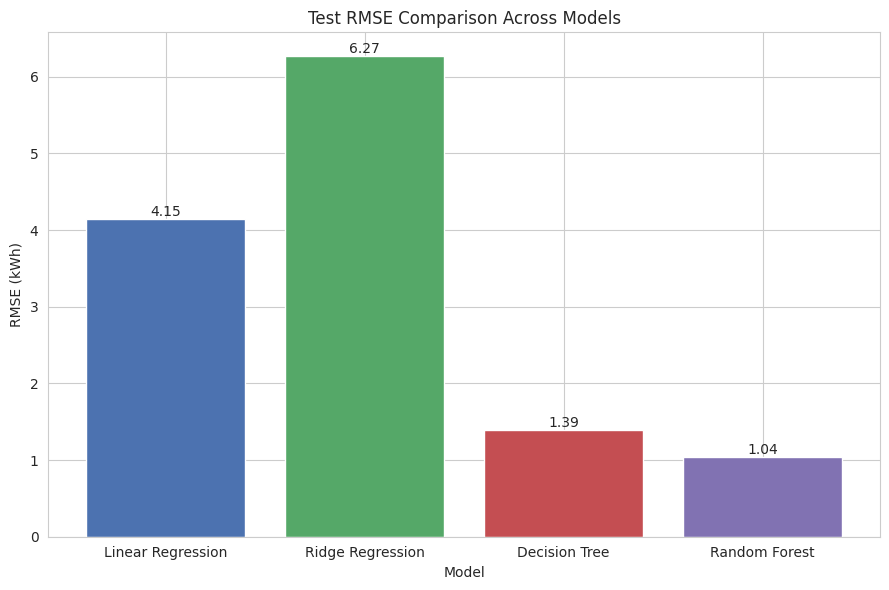

In [84]:
plt.figure(figsize = (9,6))
bars = plt.bar(results_df.index, results_df['RMSE'], color = ['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Test RMSE Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('RMSE (kWh)')

for bar, val in zip (bars, results_df['RMSE']):
  plt.text(bar.get_x() + bar.get_width()/2, val, f'{val:.2f}', ha = 'center', va = 'bottom')

plt.tight_layout()
plt.savefig('test_rmse_comparison.png', dpi = 120)
plt.show()


## 9. Predicted vs Actual- Best Model

Best model (lowest test RMSE): Random Forest


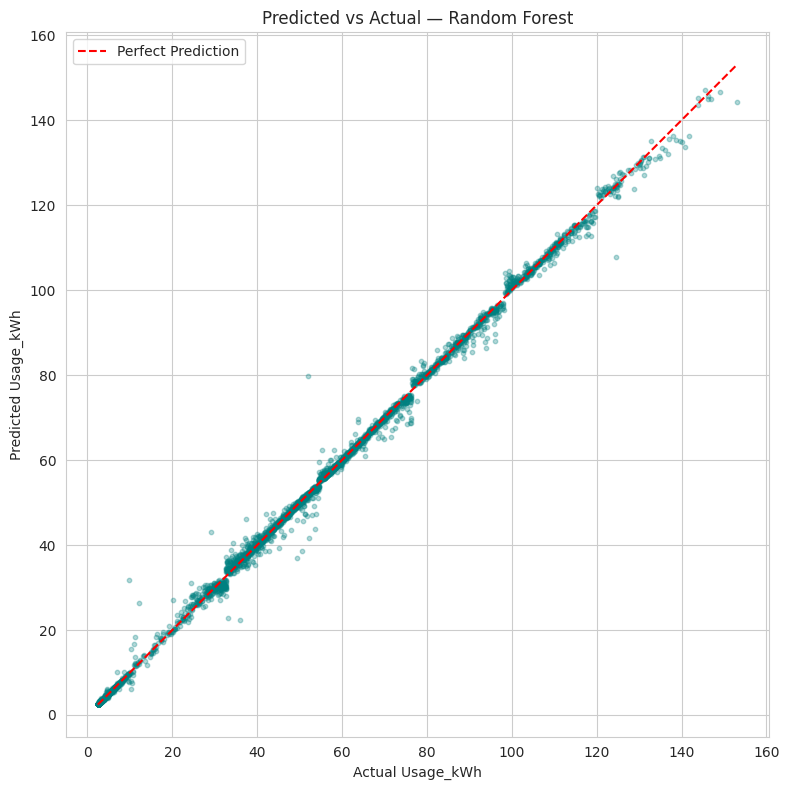

In [86]:
best_model_name = results_df['RMSE'].idxmin()
best_model = models[best_model_name]
best_preds = best_model.predict(x_test)

print (f"Best model (lowest test RMSE): {best_model_name}")

plt.figure (figsize = (8,8))
plt.scatter(y_test, best_preds, alpha = 0.3, s = 10, color = 'teal')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.xlabel('Actual Usage_kWh')
plt.ylabel('Predicted Usage_kWh')
plt.title(f'Predicted vs Actual — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual_best_model.png', dpi=120)
plt.show()

## 10. Model Selection

In [88]:
print (results_df.sort_values('RMSE'))

                        MAE      RMSE        R2  CV_RMSE_mean
Random Forest      0.347470  1.037483  0.999053      1.011050
Decision Tree      0.527063  1.387623  0.998306      1.476731
Linear Regression  2.633733  4.145640  0.984881      4.512003
Ridge Regression   4.359612  6.265433  0.965466      6.227608


**Model Selection:**
Out of the four models tested, Random Forest was chosen because it struck the best balance
between accuracy and reliability. It had the lowest prediction error (RMSE/MAE) and the
highest R² of any model, meaning its predictions were both the most accurate and explained
the most variation in energy usage. Unlike the Decision Tree — which memorized the training
data almost perfectly but performed worse on new data (overfitting) — Random Forest's
cross-validation results stayed close to its test results, proving it generalizes well to
data it hasn't seen before. And unlike Linear Regression and Ridge Regression, which were too
simple to capture the step-like jumps between Light, Medium, and Maximum load levels
(underfitting), Random Forest was flexible enough to model those real-world patterns
accurately. For these reasons, Random Forest is the model carried forward for predicting
`Usage_kWh`.